In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_PATH = "../data/raw/water_data.csv"
df = pd.read_csv(RAW_PATH)

print("Shape:", df.shape)
df.head()

Shape: (296, 26)


,row_id,timestamp,station_id,wl_t,wl_t_minus_1h,wl_t_minus_3h,wl_t_minus_6h,wl_t_minus_12h,wl_t_minus_24h,imerg_rain_1h,...,radar_reflectivity_p95,radar_reflectivity_ge20_fraction,cat_area,wsarea,mean_elevation,mean_slope,urban_ratio,forest_ratio,stream_order,target_maxrise_6h
0,1001603_2017030118,2017-03-01 18:00,1001603,1.40,1.40,1.41,1.40,1.40,1.40,0.0,...,0.0,0.0,3.5134,24.1518,912.52,20.3711,2.2483,90.2804,1.7353,0.0
1,1001603_2017041100,2017-04-11 0:00,1001603,1.56,1.56,1.56,1.57,1.57,1.58,0.0,...,0.0,0.0,3.5134,24.1518,912.52,20.3711,2.2483,90.2804,1.7353,0.0
2,1001603_2017051314,2017-05-13 14:00,1001603,1.43,1.43,1.43,1.43,1.43,1.43,0.0,...,0.0,0.0,3.5134,24.1518,912.52,20.3711,2.2483,90.2804,1.7353,0.0
3,1001605_2017040506,2017-04-05 6:00,1001605,0.94,0.94,0.94,0.94,0.92,0.93,0.0,...,0.0,0.0,3.8339,32.8339,887.36,14.5223,7.9680,67.1122,1.6579,0.0
4,1001605_2017071407,2017-07-14 7:00,1001605,1.12,1.12,1.12,1.12,1.13,1.15,0.0,...,0.0,0.0,3.8339,32.8339,887.36,14.5223,7.9680,67.1122,1.6579,0.0


In [3]:
df.dtypes

row_id                                  str
timestamp                               str
station_id                            int64
wl_t                                float64
wl_t_minus_1h                       float64
wl_t_minus_3h                       float64
wl_t_minus_6h                       float64
wl_t_minus_12h                      float64
wl_t_minus_24h                      float64
imerg_rain_1h                       float64
imerg_rain_6h                       float64
imerg_rain_24h                      float64
sfc_rain_1h                         float64
sfc_rain_6h                         float64
sfc_rain_24h                        float64
radar_reflectivity_mean             float64
radar_reflectivity_p95              float64
radar_reflectivity_ge20_fraction    float64
cat_area                            float64
wsarea                              float64
mean_elevation                      float64
mean_slope                          float64
urban_ratio                     

In [4]:
df.isnull().sum()

row_id                              0
timestamp                           0
station_id                          0
wl_t                                0
wl_t_minus_1h                       0
wl_t_minus_3h                       0
wl_t_minus_6h                       0
wl_t_minus_12h                      0
wl_t_minus_24h                      0
imerg_rain_1h                       0
imerg_rain_6h                       0
imerg_rain_24h                      0
sfc_rain_1h                         0
sfc_rain_6h                         0
sfc_rain_24h                        0
radar_reflectivity_mean             0
radar_reflectivity_p95              0
radar_reflectivity_ge20_fraction    0
cat_area                            0
wsarea                              0
mean_elevation                      0
mean_slope                          0
urban_ratio                         0
forest_ratio                        0
stream_order                        0
target_maxrise_6h                   0
dtype: int64

In [5]:
df["target_maxrise_6h"].describe()

count    296.000000
mean       0.222872
std        0.662340
min       -1.490000
25%        0.000000
50%        0.040000
75%        0.252500
max        7.070000
Name: target_maxrise_6h, dtype: float64

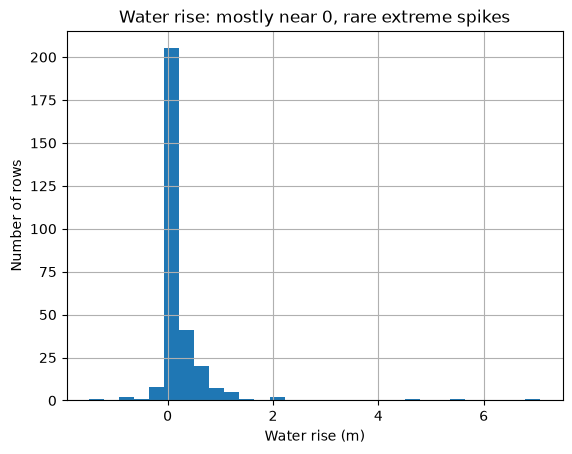

In [8]:
df["target_maxrise_6h"].hist(bins=30)
plt.xlabel("Water rise (m)")
plt.ylabel("Number of rows")
plt.title("Water rise: mostly near 0, rare extreme spikes")
plt.show()

In [ ]:
#find max rise in 6hours
df[df["target_maxrise_6h"] == df["target_maxrise_6h"].max()]

,row_id,timestamp,station_id,wl_t,wl_t_minus_1h,wl_t_minus_3h,wl_t_minus_6h,wl_t_minus_12h,wl_t_minus_24h,imerg_rain_1h,...,radar_reflectivity_p95,radar_reflectivity_ge20_fraction,cat_area,wsarea,mean_elevation,mean_slope,urban_ratio,forest_ratio,stream_order,target_maxrise_6h
277,1101696_2018092915,2018-09-29 15:00,1101696,-2.48,-2.38,-2.38,2.4,-1.59,-1.16,0.0,...,0.0,0.0,6.511,515.2043,28.46,5.1067,14.6533,17.4404,2.3333,7.07


In [11]:
# Check: does rain = 0 happen a LOT in general, even for normal/low-target rows?
# If almost the WHOLE dataset has zero rain (not just the extreme rows), 
# that's strong evidence this sample wasn't built to preserve realistic rain patterns

print("Rows where imerg_rain_6h == 0:", (df["imerg_rain_6h"] == 0).sum(), "out of", len(df))
print("Percentage:", round((df["imerg_rain_6h"] == 0).mean() * 100, 1), "%")

Rows where imerg_rain_6h == 0: 148 out of 296
Percentage: 50.0 %


In [ ]:
## 7. Feature engineering: water level trend( when the the water level chnage -0.75 the water will level up in next 6hours )
df["wl_trend_6h"] = df["wl_t"] - df["wl_t_minus_6h"]
df[["target_maxrise_6h", "wl_trend_6h"]].corr()

,target_maxrise_6h,wl_trend_6h
target_maxrise_6h,1.000000,-0.758088
wl_trend_6h,-0.758088,1.000000


In [13]:
## 8. Test robustness: does it hold without extreme outliers?
df_no_top10 = df.drop(df.nlargest(10, "target_maxrise_6h").index)
print(df_no_top10[["target_maxrise_6h", "wl_trend_6h"]].corr())

                   target_maxrise_6h  wl_trend_6h
target_maxrise_6h           1.000000    -0.483009
wl_trend_6h                -0.483009     1.000000


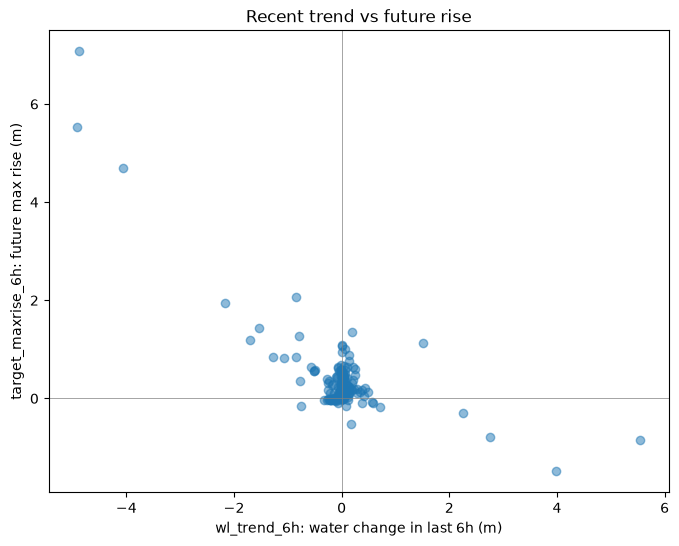

In [14]:
## 9. Visualize the relationship
plt.figure(figsize=(8,6))
plt.scatter(df["wl_trend_6h"], df["target_maxrise_6h"], alpha=0.5)
plt.xlabel("wl_trend_6h: water change in last 6h (m)")
plt.ylabel("target_maxrise_6h: future max rise (m)")
plt.title("Recent trend vs future rise")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.show()